# Week 4 Day 2 Lab


### Problem 1: Random Data Set
1. Generate a data set of size 300 using `np.random` 
2. Save this data set as a pandas dataframe
3. Download the dataset as a csv using `dataframe_name.to_csv("file_name.csv", index=False)`

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# this is just making 300 random integers from 0 to 10
data = np.random.randint(0, 11, 300)

df = pd.DataFrame({
    "values": data
})
display(df)

df.to_csv("random_data.csv", index=False)

,values
0,9
1,4
2,5
3,10
4,6
...,...
295,2
296,0
297,9
298,7


### Problem 2: Measures of Centrality
There are many ways to calculate what a data set is centered around. A few examples you have seen:

- Mean - The average of a dataset ($\bar{x}=\frac{1}{n}\sum\limits_{i=1}^nx_i$ for data points $x_i$)
- Median - The "middle data point" (average of 2 middle data points if data size is even-sized)
- Mode - The most common value (value with most number of occurences in data set)


1. Write your own function that calculate each of these.
2. Read the csv from Problem 1 into your notebook using `pd.read_csv("file_name.csv")`
3. Plot a histogram of the data and use `plt.axvline()` to plot vertical lines for the mean, median, and mode on the same histogram. 
4. Do you notice anything about the mean, median, and mode? How can you explain this behavior?

,values
0,9
1,4
2,5
3,10
4,6


4.986666666666666
5.0
0


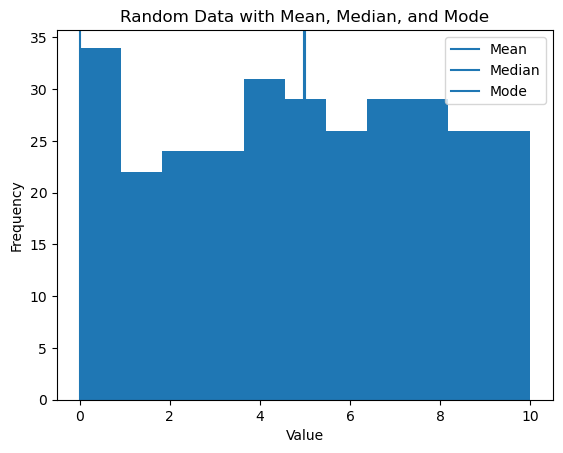

In [9]:
newdf = pd.read_csv("random_data.csv")
values = list(newdf["values"])

display(newdf.head())

def my_mean(data):
    total = 0
    for i in data:
        total = total+i
    return total/len(data)

def my_median(data):
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    if n%2 == 1:
        return sorted_data[n//2]
    else:
        middle1 = sorted_data[n//2-1]
        middle2 =sorted_data[n//2]
        return (middle1+middle2)/2
def my_mode(data):
    counts = pd.Series(data).value_counts()
    return counts.index[0]

mean_val = my_mean(values)
median_val = my_median(values)
mode_val = my_mode(values)

print(mean_val)
print(median_val)
print(mode_val)

plt.hist(values, bins=11)
plt.axvline(mean_val, label="Mean")
plt.axvline(median_val, label="Median")
plt.axvline(mode_val, label="Mode")

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Random Data with Mean, Median, and Mode")
plt.legend()
plt.show()

#Basically what can be seen is that the mean and median are usually close if the data is fairly balanced.
#but the mode will move around more because it is just the value that happened most often, which is why its pretty far from the mean and median.


### Problem 3: Measures of Variability
We don't care solely where the data is centered, but also how spread out the data is around that center. Some ways we can measure this:
- Mean Absolute Deviation - Average of distance to the mean ($MAD(x)= \frac{1}{n}\sum\limits_{i=1}^n|x_i-\bar{x}|$)
- Variance - Average squared distance to the mean ($Var(x)=\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2$)
- Standard Deviation - Square root of average squared distance to the mean ($s(x)=\sqrt{\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2}$)

where $x$ is the entire dataset, $x_i$ is a data point, and $\bar{x}$ is the mean of the dataset.

1. Write your own function that calculate each of these.
2. Plot a histogram of the data and use `plt.axvline(mean + variance)` and `plt.axvline(mean-variance)` to plot vertical lines for variance on the same histogram. Do the same with adding and subtracting mean absolute deviation and standard deviation.
3. Do you notice anything about lines corresponding to the different definitions variability? How can you explain this behavior?

MAD: 2.714666666666666
Variance: 10.04648888888891
Standard deviation: 3.169619675748008


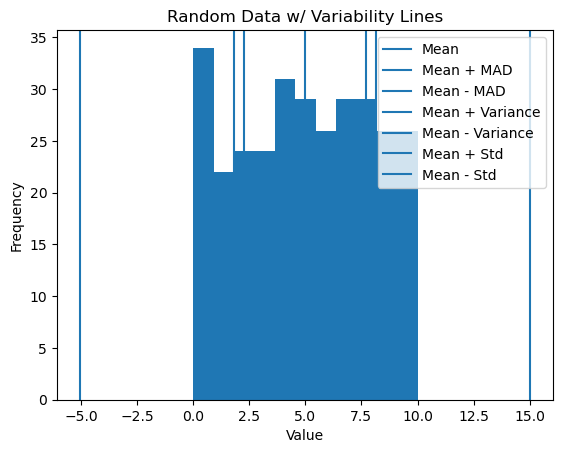

In [11]:
def my_mad(data):
    mean = my_mean(data)
    total = 0
    for i in data:
        total = total+abs(i-mean)
    return total/len(data)

def my_variance(data):
    mean = my_mean(data)
    total = 0  
    for i in data:
        total=total+(i-mean)**2
    return total/len(data)

def my_std(data):
    return my_variance(data)**0.5

mad_val = my_mad(values)
var_val = my_variance(values)
std_val = my_std(values)
print("MAD:", mad_val)
print("Variance:", var_val)
print("Standard deviation:", std_val)

plt.hist(values, bins= 11)
plt.axvline(mean_val, label="Mean")

plt.axvline(mean_val + mad_val, label = "Mean + MAD")
plt.axvline(mean_val - mad_val, label = "Mean - MAD")
plt.axvline(mean_val + var_val, label = "Mean + Variance")
plt.axvline(mean_val - var_val, label = "Mean - Variance")
plt.axvline(mean_val + std_val, label = "Mean + Std")
plt.axvline(mean_val - std_val, label = "Mean - Std")

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Random Data w/ Variability Lines")
plt.legend()
plt.show()

# MAD and standard deviation are easier and better to compare on the graph because they are at least in the same units as the data.
# Variance is squared distance, so those lines will often be farther away which will end up looking less natural.
# Standard deviation is usually bigger than MAD because it squares large distances before taking the square root.